<span style="font-size:10pt">DIADEM course "Deep Learning - Image Classification & objects detection" -- Mai 20-21, 2026 - v1.1<br> 
CC BY-SA 4.0 Jean-Luc CHARLES (Jean-Luc.charles@mailo.com)</span>

<span style="color:Sienna; font-family:arial;font-size:1.2cm; font-weight:bold">
    Hyperparameters tunning
</span>    

<p style="color:Sienna; font-family:arial; font-size:15pt;">
    In this notebook we use a simple Dense Neural Network model to illustrate the infuence of some hyperparameters on the performance of the training of a model:<br> 
    - the SEED used to make the trainings reproducible<br>
    - the <b>batch size</b> <br>
</p>    

# Preliminaries

## Import the Python modules

In [1]:
import os
# suppress tensorflow verbose warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Deep Learning modules:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import classification_report

# General modules:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pathlib import Path
from cpuinfo import get_cpu_info
import GPUtil
import sys
import random
import cv2

# local modules:
from utils.tools import (elapsed_time_since, 
                         cpu_gpu, 
                         plot_loss_accuracy, 
                         plot_loss_accuracy_vs_hyperparam, 
                         plot_proportion_bar, 
                         scan_dir, 
                         show_conf_matrix)

2026-05-18 14:27:39.494968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-18 14:27:39.506911: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-18 14:27:39.509982: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print(f"Python    : {sys.version.split()[0]}")
print(f"tensorflow: {tf.__version__} with keras {keras.__version__}")
print(f"numpy     : {np.__version__}")
print(f"OpenCV    : {cv2.__version__}")

Python    : 3.12.12
tensorflow: 2.17.0 with keras 3.14.1
numpy     : 1.26.4
OpenCV    : 4.11.0


## Global settings

In [3]:
# allows to visualize the graphs directly in the cell of the N.B.
%matplotlib inline

# SEED will be used to fix the _seed_ of the random generators to have continuations
# of repeatable random numbers
SEED = 1234

tf.get_logger().setLevel('ERROR')

## Check wether GPU is available for tensorflow or not:

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"tensorflow running on {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
        # configure tensorflow to dynamically allocate GPU memory as needed:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("tensorflow running on CPU.")

tensorflow running on CPU.


2026-05-18 14:28:00.989419: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# 1 - Prepare the MNIST dataset

<span style="color:Sienna; font-family:arial; font-size:12pt;">
   <span style="font-size:18pt;">⚠</span> To have reasonable calculation times we only take half of the MINIST dataset..
</span>

We summarize in a single cell what we have already written to load & prepare the MNIST dataset:

train:  (30000, 28, 28)
valid:  (5000, 28, 28)


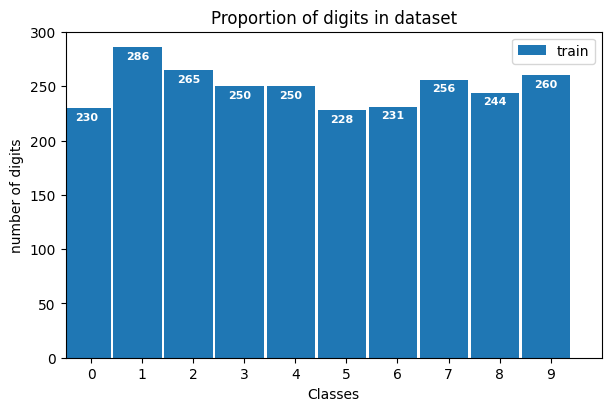

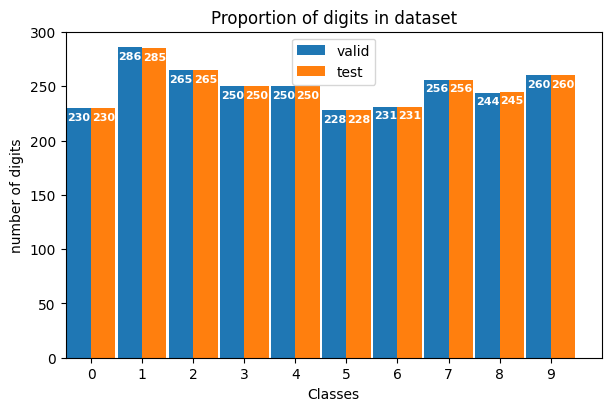

In [6]:
# 1.1 Load the MNIST dataset (images and labels)
(train_img, train_lab), (valid_img, valid_lab) = keras.datasets.mnist.load_data()

#################################
# take onky half of the dataset #
#################################
train_img = train_img[:30000]
valid_img = valid_img[:5000]
train_lab = train_lab[:30000]
valid_lab = valid_lab[:5000]
print(f'train:  {train_img.shape}')
print(f'valid:  {valid_img.shape}')
#################################

# 1.2 Create the 3 datasets: `train`, `valid` & `test`
valid_img, test_img, valid_lab, test_lab = train_test_split(valid_img, valid_lab,
                                                            stratify=valid_lab,
                                                            test_size=0.5,
                                                            shuffle=True,
                                                            random_state=SEED)
# 1.3 Check the quality of the dataset
# build the dictionnary of the classes proportion in each dataset:

prop = {}
prop['train'] = [ (valid_lab == i).sum() for i in range(10)] # list of # of 1, # of 2... in the train dataset
plot_proportion_bar(prop, range(10))

prop = {}
prop['valid'] = [ (valid_lab == i).sum() for i in range(10)] # list of # of 1, # of 2... in the valid dataset
prop['test']  = [ (test_lab  == i).sum() for i in range(10)] # list of # of 1, # of 2... in the test dataset
plot_proportion_bar(prop, range(10))

In [7]:
# 1.4 Define important parameters

NB_TRAIN_IMG = train_img.shape[0]  # number of training images
NB_VALID_IMG = valid_img.shape[0]  # number of validation images 
NB_TEST_IMG  = test_img.shape[0]   # number of test images
NB_PIXEL     = train_img[0].size   # number of elements (pixels) of the firts training image: 
NB_CLASS     = len(set(train_lab)) # number of classes:

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images and {NB_TEST_IMG} test images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

30000 training images, 2500 validation images and 2500 test images
28x28=784 pixels in each image
10 classes found in the `train_lab` ndarray


# 2 - Process input data

In [8]:
x_train = train_img.reshape(NB_TRAIN_IMG, NB_PIXEL)/255
x_valid = valid_img.reshape(NB_VALID_IMG, NB_PIXEL)/255
x_test  = test_img.reshape(NB_TEST_IMG, NB_PIXEL)/255

#check:
print(f'train: {x_train.shape}, min: {x_train.min()}, max: {x_train.max()}')
print(f'valid: {x_valid.shape}, min: {x_valid.min()}, max: {x_valid.max()}')
print(f'test : {x_test.shape}, min: {x_test.min()}, max: {x_test.max()}')

# 'one-hot' encoding' of labels :
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

train: (30000, 784), min: 0.0, max: 1.0
valid: (2500, 784), min: 0.0, max: 1.0
test : (2500, 784), min: 0.0, max: 1.0


# 3 - The Dense Neural Network (DNN)

 Now we will define a function to build a simple  **Dense Neural Network** to classify the MNIST images.<br>
 Of course, this is not the "state of the art" : convolutive NN, transformers have much more impressive scores to classify images,<br>
 but we just want want a simple model easy to understand with short training computation time.<br><br>
We will build this simple DNN:
- an **input layer** of 784 values (the pixel matrices of the 28 $\times$ 28 MNIST images flattened into vectors of 784 normalized `float` numbers),
- one **hidden layer** of 784 neurons using the `relu` activation function, with optional `dropout` regularization (will be used in section 6.2)
- an **output layer** of 10 neurons, for the classification of the 10 digits {0,1,2...9}, using the `softmax` activation function required for classifying.

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/simple-DNN.png" alt="simple-DNN.png" style="width:900px;"><br>
     [image: JLC]
</p>

In [9]:
def build_DNN(nb_input, nb_neuron, nb_class, dropout, seed=None, name=''):

    if seed is not None:
        ##########################
        # Deterministic training #
        ##########################
        # 1/ set the seed of the random generators involved by tensorflow:
        tf.keras.utils.set_random_seed(seed)
        # 2/ make the tf ops determinisctic 
        # [see https://blog.tensorflow.org/2022/05/whats-new-in-tensorflow-29.html]
        tf.config.experimental.enable_op_determinism() 

    model = Sequential()
    model.add(Input(shape=(nb_input,), name='input'))                # INPUT layer
    model.add(Dropout(dropout, seed=seed))                           # drop out rate
    model.add(Dense(nb_neuron, activation='relu', name='c1'))        # HIDDEN layer
    model.add(Dense(nb_class, activation='softmax', name='output'))  # OUTPUT layer
    
    model.compile(loss='categorical_crossentropy', optimizer='adam',  metrics=['accuracy'])
    
    if name: model.name = name
    return model

# 4 - The SEED: an important hyperparameter

## 4.1 Train the model with different SEED values

We define bellow a loop on the SEED parameter to see teh impact on the accuracy of the model trained with different values of SEED:

In [14]:
# Set the fixed hyperparameters:
DROPOUT    = 0.4
NB_NEURON  = NB_PIXEL

METRIC     = 'val_loss'
PATIENCE   = 1                  # small value to decrese computation time

NB_EPOCH   = 25
BATCH_SIZE = 32

HIST = []
for seed in (1234, 2345, 3456, 4567, 5678):
    
    t0 = time()
    print(f'\nSEED={seed}...')

    ################################################
    # 1 - Create the model with SEED set:
    ################################################
    model_name = f'DNN_seed-{seed}_drop-{DROPOUT}'
    model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, dropout=DROPOUT, seed=seed, name=model_name)

    ################################################
    # 2 - Define the Early-Stopping callback:
    ################################################
    callbacks_list = [
        EarlyStopping(monitor=METRIC,      # The metric to monitor
                      patience=PATIENCE,   # accept that the metric has 'patience' anomalies
                      restore_best_weights=True,
                      verbose=1)
    ]
    ################################################    
    # 3 - Train the model:
    ################################################
    hist = model.fit(x_train, y_train,
                     epochs=NB_EPOCH,       # the total number of successive trainings
                     batch_size=BATCH_SIZE, # fragmentation of the whole dada set in batches
                     validation_data=(x_valid, y_valid), 
                     callbacks = callbacks_list,
                     verbose=3)
    elaps = elapsed_time_since(t0)
    print(elaps)  

    ################################################
    # 4 - Save each trained model in a specific file:
    ################################################
    SEED_path = Path('model/SEED')
    SEED_path.mkdir(exist_ok=True)
    trained_name = f'{model_name}_BS-{BATCH_SIZE}__ES-{METRIC}-{PATIENCE}'
    trained_file = f'{trained_name}_trained.keras'
    trained_path = SEED_path / trained_file
    print(f'saving trained model in <{trained_path}>')
    model.save(trained_path)

    ################################################
    # 5 - Store useful parameters hist dictionnary
    ################################################
    hist.model.name           = trained_name
    hist.model.trained_path   = trained_path
    hist.params['batch_size'] = BATCH_SIZE
    hist.params['nb_epoch']   = NB_EPOCH
    hist.params['seed']       = seed
    hist.params['elaps']      = elaps
    
    HIST.append(hist)


SEED=1234...
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 5.
Elapsed time 22s -> 00:00:22
saving trained model in <model/SEED/DNN_seed-1234_drop-0.4_BS-32__ES-val_loss-1_trained.keras>

SEED=2345...
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 5.
Elapsed time 21s -> 00:00:21
saving trained model in <model/SEED/DNN_seed-2345_drop-0.4_BS-32__ES-val_loss-1_trained.keras>

SEED=3456...
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 5.
Elapsed time 21s -> 00:00:21
saving trained model in <model/SEED/DNN_seed-3456_drop-0.4_BS-32__ES-val_loss-1_trained.keras>

SEED=4567...
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 5: early stopping
Restoring model weights from the end of the be

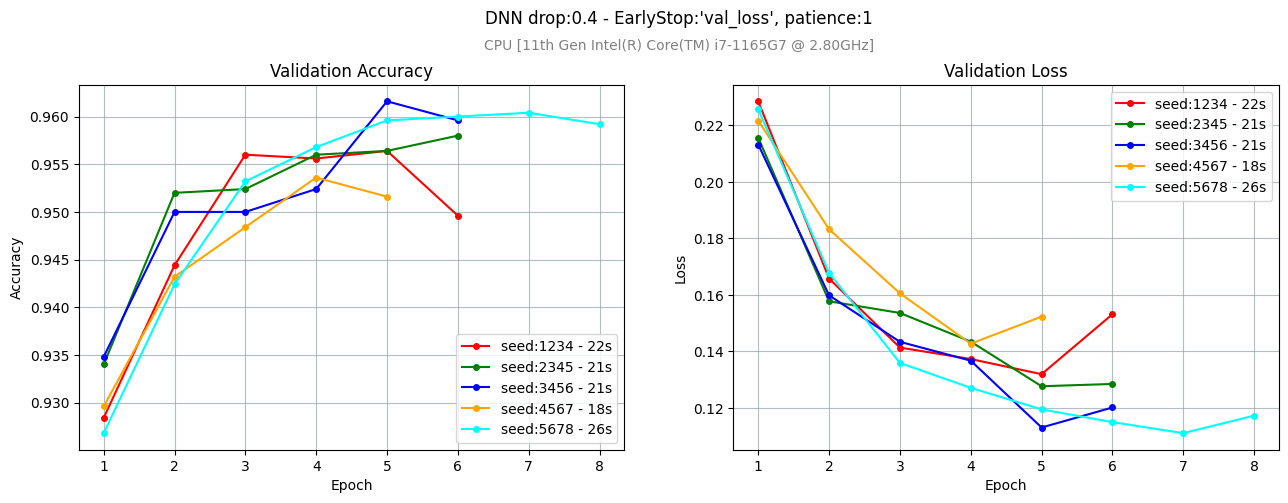

In [15]:
title = f"DNN drop:{DROPOUT} - EarlyStop:'{METRIC}', patience:{PATIENCE}"
plot_loss_accuracy_vs_hyperparam(HIST, 'seed', message=title, plot_train=False)

The `val_accuracy` and `val_loss` curves are close together but significantly different.<br>
$\leadsto$ lets's evaluate the model accuracy for the diffrent SEED values against the `test` dataset.

## 4.2 Evaluate the trained models with the `test` dataset

Now we loop over the `HIST` list to load each of the previous trained models, and we evaluate their performance against the `test` dataset:

In [15]:
TEST_ACC, TEST_LOSS = [], []

for h in HIST:
    ################################################
    # retrieve useful parameters:
    ################################################
    model_name   = h.model.name
    trained_path = h.model.trained_path
    epoch        = h.epoch
    elaps_time   = h.params['elaps'].split()[2]

    ################################################
    # load the trained model:
    ################################################
    print(f'\nLoading trained model <{trained_path.name}>')
    model = tf.keras.models.load_model(trained_path)

    ################################################
    # Evaluate the trained model against the test dataset:
    ################################################
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    ################################################
    # append the results to the lists:
    ################################################
    TEST_ACC.append(test_acc)
    TEST_LOSS.append(test_loss)
    print(f'\t test_acc: {test_acc:.3f} test_loss:{test_loss:.3f} - Elapsed time:{elaps_time:>4s}, early_stop: {len(epoch):>3d}')

# convert lists to ndarrays:
TEST_ACC, TEST_LOSS  = np.array(TEST_ACC), np.array(TEST_LOSS)

print(f'\n Average of Accuracy & loss evaluated on the TEST dataset with {len(HIST)} values of SEED:')
print(f'\t average accuracy: {TEST_ACC.mean():.3f}, std: {TEST_ACC.std():.4f}')  
print(f'\t average Loss    : {TEST_LOSS.mean():.3f}, std: {TEST_LOSS.std():.4f}')


Loading trained model <DNN_seed-1234_drop-0.4_BS-32__ES-val_loss-1_trained.keras>
	 test_acc: 0.971 test_loss:0.099 - Elapsed time: 17s, early_stop:   6

Loading trained model <DNN_seed-2345_drop-0.4_BS-32__ES-val_loss-1_trained.keras>
	 test_acc: 0.965 test_loss:0.101 - Elapsed time: 18s, early_stop:   6

Loading trained model <DNN_seed-3456_drop-0.4_BS-32__ES-val_loss-1_trained.keras>
	 test_acc: 0.976 test_loss:0.083 - Elapsed time: 18s, early_stop:   6

Loading trained model <DNN_seed-4567_drop-0.4_BS-32__ES-val_loss-1_trained.keras>
	 test_acc: 0.967 test_loss:0.106 - Elapsed time: 15s, early_stop:   5

Loading trained model <DNN_seed-5678_drop-0.4_BS-32__ES-val_loss-1_trained.keras>
	 test_acc: 0.976 test_loss:0.076 - Elapsed time: 23s, early_stop:   8

 Average of Accuracy & loss evaluated on the TEST dataset with 5 values of SEED:
	 average accuracy: 0.971, std: 0.0043
	 average Loss    : 0.093, std: 0.0115


<span style="color:maroon; font-family:arial; font-size:11pt;">
    The average accuracy  ~97.1% has low std values: it gives a significant score of the trained model when using different values of the SEED.
</span>    

# 5 - Tunning the `batch_size` hyper-parameter

## 5.2 Infuence of `batch_size` on the training 

<span style="color:maroon; font-family:arial; font-size:12pt;">
    To reveal the influence of the <b>batch_size</b> hyper-parameter we will run several trainings with different values of batch_size .<br>
</span>    

<span style="color:Blue; font-family:arial; font-size:11pt;">
    Copy/paste the training cell of the section 41.In and modify it as follow:<br>
    - the <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;SEED&thinsp;</span> is set to 1234<br>
    - The name <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;model_name&thinsp;</span> is defined before the loop<br>
    - The loop iterates with <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;bs&thinsp;</span> through the tuple <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;(16, 32, 64, 256, 512, 1024)&thinsp;</span>:<br>
    &emsp;- Build a new model with seed set<br>
    &emsp;- Define the EarlyStopping callback<br>
    &emsp;- Train the model with the argument <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;batch_size = bs&thinsp;</span><br>
    &emsp;- Set the entries  
    <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;'batch_size'&thinsp;</span>, 
    <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;'nb_epoch'&thinsp;</span>, 
    <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;seed'&thinsp;</span> and 
    <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;'elaps'&thinsp;</span> of the <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;hist.params&thinsp;</span> dictionnary to the values of corresponding parameters.
</span>

In [16]:
# Set the fixed hyperparameters:
SEED       = 1234
DROPOUT    = 0.4
NB_NEURON  = NB_PIXEL

METRIC     = 'val_loss'
PATIENCE   = 1                   # small value to decrese computation time

NB_EPOCH   = 25
BATCH_SIZE = 32

model_name = f'DNN_seed-{SEED}_drop-{DROPOUT}'

HIST = []

for bs in (16, 32, 64, 256, 512, 1024):
    print(f'batch_size={bs}')
    t0 = time()

    ################################################
    # 1 - Build a new model with seed set:
    ################################################
    model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, dropout=DROPOUT, seed=SEED, name=model_name)

    ################################################
    # 2 - define the EarlyStopping callback:
    ################################################
    callbacks_list = [
        EarlyStopping(monitor=METRIC,      # The metric to monitor
                      patience=PATIENCE,   # accept that 'val_accuracy' decrease 'patience' times
                      restore_best_weights=True,
                      verbose=1)
    ]
    ################################################
    # 3 - Train the model:
    ################################################
    hist = model.fit(x_train, y_train, # images, labels
                     epochs=NB_EPOCH,  # the total number of successive trainings
                     batch_size=bs,    # split the train dataset in multiple batches
                     validation_data=(x_valid, y_valid), 
                     callbacks = callbacks_list,
                     verbose=3)
    elaps = elapsed_time_since(t0)
    print(f' Train {elaps}\n', flush=True) 

    ################################################
    # 4 - Store useful parameters the hist dictionnary
    ################################################
    hist.params['batch_size'] = bs
    hist.params['nb_epoch']   = NB_EPOCH
    hist.params['seed']       = SEED
    hist.params['elaps']      = elaps
    
    HIST.append(hist)

batch_size=16
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 3.
 Train Elapsed time 21s -> 00:00:21

batch_size=32
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 5.
 Train Elapsed time 18s -> 00:00:18

batch_size=64
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 3.
 Train Elapsed time 7s -> 00:00:07

batch_size=256
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 7/25
Epoch 8/25
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 7.
 Train Elapsed time 7s -> 00:00:07

batch_size=512
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 7/25
Epoch 8/25
Epoch 9/25
Epoch 10/25
Epoch 11/25
Epoch 12/25
Epoch 13/25
Epoch 14/25
Epoch 14: early stopping
Restoring model weights 

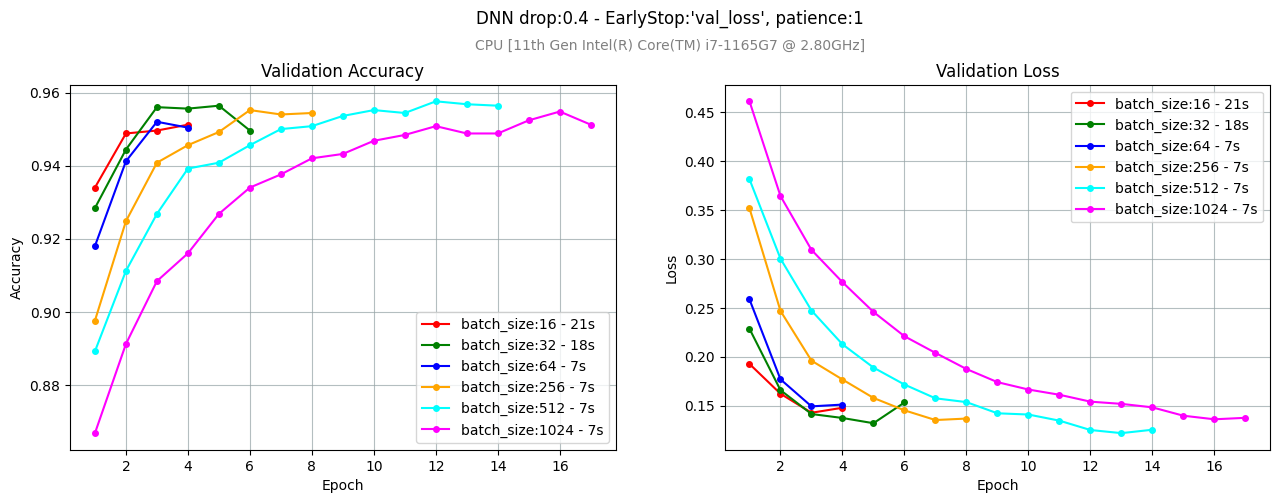

In [17]:
title = f"DNN drop:{DROPOUT} - EarlyStop:'{METRIC}', patience:{PATIENCE}"
plot_loss_accuracy_vs_hyperparam(HIST, 'batch_size', message=title, plot_train=False)

<span style="color:maroon; font-family:arial; font-size:12pt;">
    $\leadsto$ The influence of the hyper-parmeter <b>batch_size</b> appears clearly<br>
    We will implement a cross-validation procedure to find out the value of <b>batch_size</b> giving the best trained model.
</span>    

## 7.2 Tuning `batch_size` with Cross-validation

We define the `batch_size-_CV` function to reliabily evaluate the model performance for different values of the `batch_size`parameter, thanks to the Cross-Validation (Strafied K-Fold): 

In [23]:
def batch_size_CV(seed,            # the value to use for the SEED
                   dropout,         # the value of the dropout
                   metric,          # metric to monitor for Early-stop
                   patience,        # Early-stop patience parameter
                   nb_split,        # Cross-validation number of splits
                   batch_size_list  # list of the batch_size values 
                   ):

    NB_EPOCH  = 25
    NB_NEURON = NB_PIXEL

    skf = StratifiedKFold(n_splits=nb_split, shuffle=True, random_state=seed)

    # Define an empty dictionnary to store the computed data:
    EVAL = {}

    ###############################################
    # Loop over the values of the hyper-parameter #
    ###############################################
    for bs in batch_size_list:
     
        print(f'\nbatch_size={bs}')
        t0 = time()

        ###############################################
        # Empty the lists used to store the CV results:
        ###############################################
        VAL_ACC, VAL_LOSS = [], []

        ###############################################
        # Cross_validation evaluation
        ###############################################
        for s, (train_index, valid_index) in enumerate(skf.split(x_train, train_lab)):
            print(f'\t Split #{s + 1}')

            ###############################################
            # Build the different folds:
            ###############################################
            x_train_CV, y_train_CV = x_train[train_index], y_train[train_index]
            x_valid_CV, y_valid_CV = x_train[valid_index], y_train[valid_index]

            ###############################################
            # define the EarlyStopping callback:
            ###############################################
            callbacks_list = [
                EarlyStopping(monitor=metric,     # The parameter to monitor
                              patience=patience,   # accept that 'val_accuracy' decrease 'patience' times
                              restore_best_weights=True,
                              verbose=0)
            ]
            ###############################################
            # Build the model with SEED and dropout:
            ###############################################
            model_name = f'DNN_seed-{seed}_drop-{dropout}'
            model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, dropout=dropout, seed=seed, name=model_name)

            ###############################################
            # Train the model:             
            ###############################################
            hist = model.fit(x_train_CV, y_train_CV,
                             validation_data=(x_valid_CV, y_valid_CV), 
                             epochs=NB_EPOCH,       # the max number of successive trainings
                             batch_size=bs,         # fragmentation of the whole dada set in batches
                             callbacks = callbacks_list,
                             verbose=0)

            ###############################################
            # Save each trained model in a specific file:
            ###############################################
            BS_CV_path = Path('model/batch_size-CV')
            BS_CV_path.mkdir(exist_ok=True)
            trained_name = f'{model_name}_BS-{bs}__ES-{metric}-{patience}_SPLIT-{s+1:02d}on{nb_split}'
            trained_file = f'{trained_name}_trained.keras'
            trained_path = BS_CV_path / trained_file

            ###############################################
            # evaluate the model against the validation dataset: 
            ###############################################
            val_loss, val_acc = model.evaluate(x_valid_CV, y_valid_CV, verbose=0)   
            VAL_ACC.append(val_acc)
            VAL_LOSS.append(val_loss)

        VAL_ACC, VAL_LOSS = np.array(VAL_ACC), np.array(VAL_LOSS)
    
        print(f'\t Validation accuracy & loss evaluated with {NB_SPLIT} folds:')
        print(f'\t\t Average accuracy: {VAL_ACC.mean():.3f}, std: {VAL_ACC.std():.4f}')  
        print(f'\t\t Average loss    : {VAL_LOSS.mean():.3f}, std: {VAL_LOSS.std():.4f}\n')

        # Define an entry in the dictionnary for this value of bs which store the traing metrics:
        EVAL[bs] = [VAL_ACC.mean(), VAL_LOSS.mean()]
        
    return EVAL 

<span style="color:Blue; font-family:arial; font-size:11pt;">
In the cell below:<br>
- Define the parameters required to call the <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;batch_size_CV&thinsp;</span> function<br>
- Run the <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;batch_size_CV&thinsp;</span> with the list <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;(32, 64, 128, 512, 1024)&thinsp;</span><br>
- Name <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;EVAL&thinsp;</span> the data returned by <span style="font-family:monospace; background-color: #EBEBEB;">&thinsp;batch_size_CV&thinsp;</span> 
</span>

In [24]:
# Set the fixed hyperparameters:
SEED       = 1234
DROPOUT    = 0.4
METRIC     = 'val_loss'
PATIENCE   = 1

# Training dataset divided into 5 folds:
NB_SPLIT   = 5     

t0 = time()

# Run the Croos-Validation:
EVAL = batch_size_CV(SEED, DROPOUT, METRIC, PATIENCE, NB_SPLIT, (32, 64, 128, 512, 1024))
print(elapsed_time_since(t0))


batch_size=32
	 Split #1
	 Split #2
	 Split #3
	 Split #4
	 Split #5
	 Validation accuracy & loss evaluated with 5 folds:
		 Average accuracy: 0.972, std: 0.0018
		 Average loss    : 0.089, std: 0.0062


batch_size=64
	 Split #1
	 Split #2
	 Split #3
	 Split #4
	 Split #5
	 Validation accuracy & loss evaluated with 5 folds:
		 Average accuracy: 0.973, std: 0.0042
		 Average loss    : 0.088, std: 0.0128


batch_size=128
	 Split #1
	 Split #2
	 Split #3
	 Split #4
	 Split #5
	 Validation accuracy & loss evaluated with 5 folds:
		 Average accuracy: 0.976, std: 0.0015
		 Average loss    : 0.080, std: 0.0071


batch_size=512
	 Split #1
	 Split #2
	 Split #3
	 Split #4
	 Split #5
	 Validation accuracy & loss evaluated with 5 folds:
		 Average accuracy: 0.973, std: 0.0043
		 Average loss    : 0.089, std: 0.0144


batch_size=1024
	 Split #1
	 Split #2
	 Split #3
	 Split #4
	 Split #5
	 Validation accuracy & loss evaluated with 5 folds:
		 Average accuracy: 0.974, std: 0.0022
		 Average loss  

EVAL is a dictionnary:

In [20]:
EVAL

{32: [0.9720666766166687, 0.08914340883493424],
 64: [0.9732999920845031, 0.08834904134273529],
 128: [0.9763999819755554, 0.07995152175426483],
 512: [0.9733333230018616, 0.08860157728195191],
 1024: [0.9744666576385498, 0.08729701340198517]}

`EVAL.values()` gives the keys of the dictionnary:

In [26]:
list(EVAL.values())

[[0.9720666766166687, 0.08914340883493424],
 [0.9732999920845031, 0.08834904134273529],
 [0.9763999819755554, 0.07995152175426483],
 [0.9733333230018616, 0.08860157728195191],
 [0.9744666576385498, 0.08729701340198517]]

Now we must find out a way to get which row of `Eval.values()` has the max accuracy (in the firts column) ?

`np.argmax(np.array(list(EVAL.values())), axis=n)` gives the rank of the max value for the axis n in the array `np.array(list(EVAL.values()))`:

Following `axis=0` gives:

In [22]:
np.argmax(np.array(list(EVAL.values())), axis=0)

array([2, 0])

Following `axis=1` gives:

In [23]:
np.argmax(np.array(list(EVAL.values())), axis=1)

array([0, 0, 0, 0, 0])

$\leadsto$ we can get the rank of the max value in the first columns of `EVAL.values` :

In [29]:
# rannk of the max value of the accuracy:
max_acc_rank = np.argmax(np.array(list(EVAL.values())), axis=0)[0]

# corresponding key in the dictionnary:
best_bs = list(EVAL.keys())[max_acc_rank]

print(f'Best batch_size for the best accuracy of the model: {best_bs}')

Best batch_size for the best accuracy of the model: 128
